# 데이터 전처리 Preprocessing
- 데이터 클렌징: 결측치/중복값/이상치 처리
- 데이터 인코딩: 문자값 수치로 변환 (LabelEncoding, OneHotEncoding)
- 데이터 스케일링: 표준정규화, 최대/최소정규화, RobustScaler. KNN/SVM/KMeans처럼 거리나 크기를 보는 모델에서 큰 숫자 feature가 판단을 지배하지 않게 하기 위함.
- 특성공학:
  - 특성선택/추출
  - 가공
  - 다항처리


In [1]:
# 초기 세팅용 import 구문입니다. 먼저 실행한 뒤 실습 코드를 작성합니다.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.datasets import load_iris


## 데이터 클렌징
- 결측치/중복값/이상치 처리



#### `SimpleImputer`: 결측치를 평균, 중앙값, 최빈값 등 지정한 전략으로 대체함.


In [2]:
from sklearn.impute import SimpleImputer

# 결측치가 포함된 데이터
data = pd.DataFrame({
    "age": [25, None, 27, None, 30],
    "income": [50000, 60000, None, 52000, 58000]
})

# SimpleImputer() : 결측치 전처리기 생성
imputer = SimpleImputer(strategy="mean") # mean 전략이 기본값

# imputer.fit_transform(data) : data 학습 후 결측치를 mean으로 변환
data_cleaned = pd.DataFrame(
    imputer.fit_transform(data),
    columns=data.columns
)

data_cleaned # None -> 평균 값 변환 확인

,age,income
0,25.000000,50000.0
1,27.333333,60000.0
2,27.000000,55000.0
3,27.333333,52000.0
4,30.000000,58000.0


`IsolateionForest()` : 이상치 탐지 모델 (트리 기반)

In [5]:
# 이상치 처리
from sklearn.ensemble import IsolationForest

# 100이 이상치 후보
X = np.array([[1], [2], [2.5], [3], [100]])

# 이상치 탐지 모델 생성
# 정상 데이터는 여러 번 잘라야 격리, 이상치는 적게 잘라도 격리된다는 아이디어로 만들어진 모델
iso = IsolationForest(random_state=42)

# fit(): 학습
# prefict(): 예측 -> 정상은 1, 이상치는 -1로 표기
pred = iso.fit_predict(X)
print(pred)  # [ 1  1  1  1 -1]

X_cleaned = X[pred == 1]
print(X_cleaned)

[ 1  1  1  1 -1]
[[1. ]
 [2. ]
 [2.5]
 [3. ]]


## 데이터 인코딩 - 범주형 인코딩
- 문자 범주를 모델이 계산할 수 있는 숫자 표현으로 바꾸는 과정.


#### `LabelEncoder`: 문자 범주를 0, 1, 2 같은 정수 라벨로 변환함.


In [7]:
from sklearn.preprocessing import LabelEncoder

items = ['TV', '냉장고', '전자렌지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서']

encoder = LabelEncoder()

encoder.fit(items) # 데이터를 학습하고, 내부적으로 정렬된 클래스 목록을 생성

labels = encoder.transform(items)
print(labels)

# 클래스 목록 확인
print(encoder.classes_)

[0 1 4 5 3 3 2 2]
['TV' '냉장고' '믹서' '선풍기' '전자렌지' '컴퓨터']


In [8]:
# 정수형 label 복원 작업(문자 범주)
encoder.inverse_transform([2, 3, 1])

array(['믹서', '선풍기', '냉장고'], dtype='<U4')

### One-hot Encoding : 범주형 변수마다 하나의 컬럼을 생성하고, 해당 범주에만 1을 표시하는 인코딩
### (one vs. rest 또는 one vs. all)


In [16]:
from sklearn.preprocessing import OneHotEncoder

items = ['TV', '냉장고', '전자렌지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서']

print(len(items)) # 8

# OneHotEncoder 객체 생성 시 입력되는 데이터 X는 항상 2차원 형태여야함
# reshape에서 -1 == 자동으로, 알아서 --> 여기서는 8로 계산됨
items = np.array(items).reshape(-1, 1)
# print(items)

encoder = OneHotEncoder()
encoder.fit(items) # 학습 후 각 범주가 어느 컬럼에 대응 되는지 정함
print(encoder.categories_)

# 각 데이터를 해당 범주 컬럼만 1로 바꾸고 나머지는 0인 벡터로 변환함
one_hot_items = encoder.transform(items)
print(one_hot_items.toarray())

8
[array(['TV', '냉장고', '믹서', '선풍기', '전자렌지', '컴퓨터'], dtype='<U4')]
[[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]


## 피처 스케일링과 정규화
머신러닝에서 **피처 스케일링**은 서로 다른 범위를 가지는 데이터를 공통된 기준으로 맞추기 위한 과정이다.
### 표준화 (Standardization)
- **정의**: 평균을 0, 표준편차를 1로 변환하는 방식
- **공식**:
  $$
  z = \frac{x - \mu}{\sigma}
  $$
  여기서 $ \mu $는 평균, $ \sigma $는 표준편차
- **특징**:
  - 데이터가 **정규분포를 따를 때** 효과적
  - **음수 값도 허용**
  - 이상치(outlier)의 영향을 **덜 받음**

---

### 정규화 (Normalization, Min-Max Scaling)
- **정의**: 데이터를 0과 1 사이로 스케일링
- **공식**:
  $$
  x_{norm} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
  $$
- **특징**:
  - **특정 범위(보통 0~1)**로 제한
  - **이상치에 민감**
  - 거리 기반 알고리즘(k-NN, SVM 등)에 자주 사용

---

### 로버스트 스케일링 (Robust Scaling)
- **정의**: 중앙값(Median)과 사분위 범위(IQR)를 이용한 스케일링
- **공식**:
  $$
  x_{scaled} = \frac{x - \text{Median}}{\text{IQR}}
  $$
  여기서 IQR = Q3 - Q1 (제3사분위수 - 제1사분위수)
- **특징**:
  - **이상치에 강건(Robust)**
  - 중앙값과 IQR 기준 → **데이터 분포 왜곡이 적음**
  - **StandardScaler보다 이상치 영향이 적은 대안**
  - 다양한 분포의 데이터에 적용 가능


In [17]:
from sklearn.datasets import load_iris

iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 데이터 스케일링

#### StandardScaler: 평균 0, 표준편차 1 기준으로 수치 feature의 단위를 맞춤.


In [18]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

# 제공된 데이터를 학습해서 각 컬럼의 평균과 표준편차를 구함
standard_scaler.fit(iris_df)

iris_scaled_df = pd.DataFrame(
    standard_scaler.transform(iris_df), # 스케일러로 변환한 데이터
    columns=iris_df.columns # 기존 iris_df 컬럼명 그대로 사용
)

iris_scaled_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832
146,0.553333,-1.282963,0.705921,0.922303
147,0.795669,-0.131979,0.819596,1.053935
148,0.432165,0.788808,0.933271,1.448832


#### MinMaxScaler: 최소값 0, 최대값 1 범위로 수치 feature의 범위를 맞춤.


In [19]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

# 제공된 데이터를 학습해서 각 컬럼(Feature)의 최솟값을 0, 최댓값을 1로 맞춤
minmax_scaler.fit(iris_df)

iris_scaled_df = pd.DataFrame(
    minmax_scaler.transform(iris_df), # 스케일러로 변환한 데이터
    columns=iris_df.columns # 기존 iris_df 컬럼명 그대로 사용
)

iris_scaled_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667
...,...,...,...,...
145,0.666667,0.416667,0.711864,0.916667
146,0.555556,0.208333,0.677966,0.750000
147,0.611111,0.416667,0.711864,0.791667
148,0.527778,0.583333,0.745763,0.916667


#### RobustScaler: 중앙값과 IQR을 기준으로 스케일링해 이상치 영향을 줄임.


In [21]:
from sklearn.preprocessing import RobustScaler
X = np.array([[10],[12],[14],[100]])

robust_scaler = RobustScaler()

# 각 컬럼의 중앙값과 IQR을 학습
robust_scaler.fit(X)

X_scaled = robust_scaler.transform(X)
X_scaled


array([[-0.125     ],
       [-0.04166667],
       [ 0.04166667],
       [ 3.625     ]])

## 데이터 스케일링

- StandardScaler: 평균 0, 표준편차 1 기준으로 수치 feature의 단위를 맞춤.
- MinMaxScaler: 최소값 0, 최대값 1 범위로 수치 feature의 범위를 맞춤.
- RobustScaler: 중앙값과 IQR을 기준으로 스케일링해 이상치 영향을 줄임.


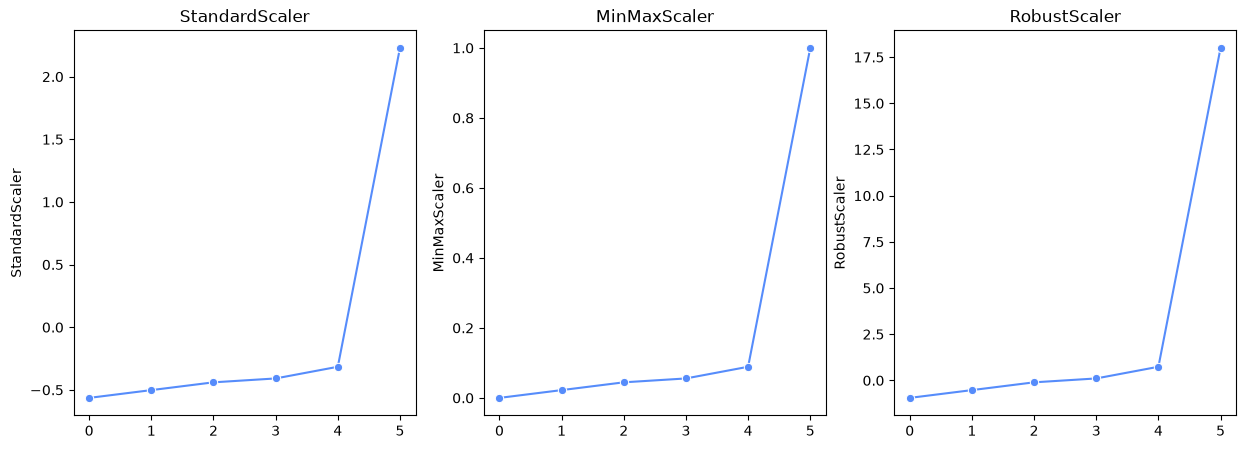

In [22]:
df = pd.DataFrame([[10], [12], [14], [15], [18], [100]], columns=['Original'])

# 같은 원본 데이터에 세 가지 스케일링을 각각 적용함.
df['StandardScaler'] = StandardScaler().fit_transform(df[['Original']])
df['MinMaxScaler'] = MinMaxScaler().fit_transform(df[['Original']])
df['RobustScaler'] = RobustScaler().fit_transform(df[['Original']])

# 1행 3열 그래프로 스케일러별 결과를 나란히 비교함.
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# StandardScaler: 평균/표준편차 기반이라 이상치가 평균과 표준편차를 왜곡할 수 있음.
sns.lineplot(df['StandardScaler'], ax=ax[0], marker='o')
ax[0].set_title('StandardScaler')

# MinMaxScaler: 최솟값/최댓값 기반이라 이상치 하나가 전체 범위를 크게 늘릴 수 있음.
sns.lineplot(df['MinMaxScaler'], ax=ax[1], marker='o')
ax[1].set_title('MinMaxScaler')

# RobustScaler: 중앙값/IQR 기반이라 이상치 영향이 상대적으로 작음.
sns.lineplot(df['RobustScaler'], ax=ax[2], marker='o')
ax[2].set_title('RobustScaler')

plt.show()